In [60]:
import pandas as pd
# from langchain_gigachat import GigaChat
from langgraph.graph import MessagesState
from langchain_core.messages import AIMessage, HumanMessage, SystemMessage
from langgraph.graph import START, StateGraph, END
from langgraph.prebuilt import tools_condition, ToolNode
from IPython.display import Image, display
from langgraph.checkpoint.memory import MemorySaver
from langchain_openai import ChatOpenAI
from langchain_core.prompts import ChatPromptTemplate
from typing import Annotated, List, Tuple, Union, Literal, Dict
from typing_extensions import TypedDict
from pydantic import BaseModel, Field
import os
from dotenv import load_dotenv
from langchain_core.documents import Document
from langchain_community.embeddings import HuggingFaceEmbeddings
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_community.vectorstores import FAISS
from langchain.retrievers import BM25Retriever, EnsembleRetriever
from langchain_community.document_loaders.csv_loader import CSVLoader
import pandas as pd
import re
import subprocess
from tabulate import tabulate

from tqdm import tqdm
import json
import pandas as pd
import os
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score

In [61]:
from dotenv import load_dotenv
load_dotenv()

gigatoken = os.getenv('credentials')
chatgpt_token = os.getenv('OPENAI_API_KEY')


### Критерии оценки:
* 1  Входим корректно в сценарий по условиям входа (тестируем на большом обьеме синтетики


In [62]:
dataset = pd.read_csv('scenarios_with_funcs.csv')
dataset.index.name = "Index"
dataset = dataset[dataset['target'] != -1]
dataset

,scene_name,entry_condition,user_message,category,target,scene_text,funcs
Index,,,,,,,
0,Устранение проблем с блокировкой карты,Запрос пользователя связан с одной из перечисл...,"Я не могу использовать свою карту, она, похоже...",Проблемы с картами,1,Идентификация причины блокировки карты. Провер...,"[""check_transaction_history(), confirm_custome..."
1,Подтверждение транзакции,Запрос пользователя связан с одной из перечисл...,Я не вижу на своем счете транзакцию за 5000 ру...,Транзакции,1,Проверка данных транзакции. Верификация источн...,"[""verify_fund_source(), check_transaction_stat..."
2,Проверка статуса страхового полиса,Запрос пользователя связан с одной из перечисл...,Какой статус моего страхового полиса?,Страхование,1,Проверка идентификационной информации клиента....,"[""check_policy_status(), suggest_policy_terms(..."
3,Консультация по инвестиционным стратегиям,Запрос пользователя связан с одной из перечисл...,Какой у вас курс валюты на сегодня?,Инвестиции,0,Анализ финансовых целей клиента. Оценка рисков...,"[""suggest_investment_options()""]"
4,Оформление кредита,Запрос пользователя связан с одной из перечисл...,"Может, расскажете про кредиты? Интересно, что ...",Кредитование,1,Проверка кредитоспособности клиента. Сбор необ...,"[""collect_documents(), suggest_credit_products..."
...,...,...,...,...,...,...,...
190,Проверка активности счета,Запрос пользователя связан с одной из перечисл...,У меня на счету появилось какое-то подозритель...,Безопасность счета,1,Идентификация клиента. Запрос информации о пос...,"[""fetch_recent_transactions()""]"
191,Блокировка банковской карты при утере,Запрос пользователя связан с одной из перечисл...,"Слушай, кажется, я оставил карту в другом горо...",Проблемы с картами,1,Получение информации о состоянии карты. Провер...,"[""verify_client_data(), locate_last_activity()..."
192,Проверка статуса транзакции,Запрос пользователя связан с одной из перечисл...,"Я хочу узнать, прошла ли моя последняя транзак...",Транзакции,1,Получение информации о транзакции. Проверка ст...,"[""check_transaction_status()"", ""analyze_delay_..."


In [63]:
import json
import pandas as pd

def decode_unicode_column(dataset, column_name='funcs'):
    """Декодирует значения в указанной колонке, если они в формате Unicode."""
    decoded_funcs = []
    for funcs in dataset[column_name]:
        if isinstance(funcs, str):
            try:
                decoded = json.loads(funcs)
                decoded_funcs.append(decoded)
            except json.JSONDecodeError:

                decoded_funcs.append(funcs)
        else:
            decoded_funcs.append(funcs)
    dataset[column_name] = decoded_funcs

decode_unicode_column(dataset, 'funcs')
dataset['funcs'].head()


Index
0    [check_transaction_history(), confirm_customer...
1    [verify_fund_source(), check_transaction_statu...
2    [check_policy_status(), suggest_policy_terms()...
3                       [suggest_investment_options()]
4     [collect_documents(), suggest_credit_products()]
Name: funcs, dtype: object

<Axes: >

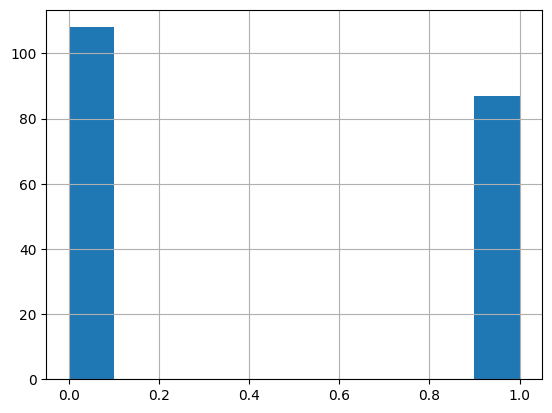

In [64]:
dataset.target.hist()

In [65]:
dataset

,scene_name,entry_condition,user_message,category,target,scene_text,funcs
Index,,,,,,,
0,Устранение проблем с блокировкой карты,Запрос пользователя связан с одной из перечисл...,"Я не могу использовать свою карту, она, похоже...",Проблемы с картами,1,Идентификация причины блокировки карты. Провер...,"[check_transaction_history(), confirm_customer..."
1,Подтверждение транзакции,Запрос пользователя связан с одной из перечисл...,Я не вижу на своем счете транзакцию за 5000 ру...,Транзакции,1,Проверка данных транзакции. Верификация источн...,"[verify_fund_source(), check_transaction_statu..."
2,Проверка статуса страхового полиса,Запрос пользователя связан с одной из перечисл...,Какой статус моего страхового полиса?,Страхование,1,Проверка идентификационной информации клиента....,"[check_policy_status(), suggest_policy_terms()..."
3,Консультация по инвестиционным стратегиям,Запрос пользователя связан с одной из перечисл...,Какой у вас курс валюты на сегодня?,Инвестиции,0,Анализ финансовых целей клиента. Оценка рисков...,[suggest_investment_options()]
4,Оформление кредита,Запрос пользователя связан с одной из перечисл...,"Может, расскажете про кредиты? Интересно, что ...",Кредитование,1,Проверка кредитоспособности клиента. Сбор необ...,"[collect_documents(), suggest_credit_products()]"
...,...,...,...,...,...,...,...
190,Проверка активности счета,Запрос пользователя связан с одной из перечисл...,У меня на счету появилось какое-то подозритель...,Безопасность счета,1,Идентификация клиента. Запрос информации о пос...,[fetch_recent_transactions()]
191,Блокировка банковской карты при утере,Запрос пользователя связан с одной из перечисл...,"Слушай, кажется, я оставил карту в другом горо...",Проблемы с картами,1,Получение информации о состоянии карты. Провер...,"[verify_client_data(), locate_last_activity(),..."
192,Проверка статуса транзакции,Запрос пользователя связан с одной из перечисл...,"Я хочу узнать, прошла ли моя последняя транзак...",Транзакции,1,Получение информации о транзакции. Проверка ст...,"[check_transaction_status(), analyze_delay_cau..."


## Графф для инфера

### Base начало модели с дефолтными функциями.

In [66]:
def generate_test_code(exp_n,model = None):
    save_path = f"test_gen_{exp_n}.py"

    def process_generators():
        """Процесс генерации с учётом получения инструментов для сценариев."""
        base_import = '''import warnings
warnings.filterwarnings("ignore")
from langchain_gigachat import GigaChat
from langgraph.graph import MessagesState
from langchain_core.messages import AIMessage, HumanMessage, SystemMessage
from langgraph.graph import START, StateGraph, END
from langgraph.prebuilt import tools_condition, ToolNode
from langchain_core.tools import tool
from IPython.display import Image, display
from langgraph.checkpoint.memory import MemorySaver
from langchain_openai import ChatOpenAI
from langchain_core.prompts import ChatPromptTemplate
from typing import Annotated, List, Tuple, Union, Literal, Dict
from typing_extensions import TypedDict
from pydantic import BaseModel, Field
import os
from dotenv import load_dotenv
from langchain_core.documents import Document
from langchain_huggingface import HuggingFaceEmbeddings
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_community.vectorstores import FAISS
from langchain_community.retrievers import BM25Retriever
from langchain_community.document_loaders.csv_loader import CSVLoader
import pandas as pd
import re
import ast
from langgraph.prebuilt import create_react_agent
from langchain_community.tools.tavily_search import TavilySearchResults
# Загружаем переменные окружения из .env файла
load_dotenv()

# Получаем API-ключ из переменной окружения
creds = os.getenv('credentials')
openaitoken = os.getenv('OPENAI_API_KEY')

from tabulate import tabulate

# llm = ChatOpenAI(
#     model="gpt-4o-mini", temperature=0.1
# )
'''    
        if model == "GigaChat-Max":
            llm_import = '''
llm = GigaChat(
        credentials = creds,
        verify_ssl_certs=False,
        scope = 'GIGACHAT_API_CORP',
        temperature=0.1,
        # model="GigaChat",
        model="GigaChat-Max",
        
        # model="GigaChat-Max-preview",
        # base_url="https://gigachat-preview.devices.sberbank.ru/api/v1/"       
    )
    '''
        elif model == "GigaChat":
                llm_import = '''
llm = GigaChat(
        credentials = creds,
        verify_ssl_certs=False,
        scope = 'GIGACHAT_API_CORP',
        temperature=0.1,
        model="GigaChat"
        
        # model="GigaChat-Max-preview",
        # base_url="https://gigachat-preview.devices.sberbank.ru/api/v1/"       
    )
        '''
        elif model == "gpt-o1_mini":
            llm_import = '''
llm = ChatOpenAI(
    model="gpt-4o-mini", temperature=0.1,api_key= openaitoken
)
    '''
        base_import_2= '''
print(f"ТЕСТИРУЕМ АНЕКДОТ ОТ ЛЛМ: {llm.invoke('Расскажи анектод')}")

choose_question_rag_prompt = """
Роль:
Ты — агент, выбирающий наиболее подходящий вопрос к вопросу пользователя.

Задание:
1. Проанализируй предоставленные вопросы и вопрос пользователя.
2. Верни наиболее похожий вопрос, либо ответь что похожего вопроса нет.

Предоставленные вопросы:
{context}

Вопрос пользователя:
{question}

Твоя задача — вернуть из предоставленных вопросов вопрос наиболее похожий на вопрос пользователя, либо сообщить об отсутствии такого вопроса (верни 'no'). В ответе должен быть только текст наиболее подходящего вопроса.
Внимание: Удостоверься, что пунктуация возвращаемого тобой вопроса совпадает с той, которая была в момент предоставления вопросов (если в предоставленном вопросе в конце не было знака вопроса, то его добавлять не нужно).
"""

choose_question_rag_template = ChatPromptTemplate.from_template(choose_question_rag_prompt)

question_choose_agent = choose_question_rag_template | llm


def get_embeddings():
    model_name = "sentence-transformers/paraphrase-multilingual-mpnet-base-v2"
    model_kwargs = {'device': 'cpu'}
    encode_kwargs = {'normalize_embeddings': False}
    embedding = HuggingFaceEmbeddings(
        model_name=model_name,
        model_kwargs=model_kwargs,
        encode_kwargs=encode_kwargs
        )
    return embedding

def prep_bd():
    file_path = '/home/maksim-litvninov/Documents/'
    vector_store_loaded = FAISS.load_local(folder_path=file_path, embeddings=get_embeddings(), allow_dangerous_deserialization= True)
    loaded_retriever = vector_store_loaded.as_retriever(search_kwargs={'k': 3}, search_type="mmr")
    return loaded_retriever
    '''
        
        base_tools = """
@tool
def factual_questions(user_question: str) -> str:
    '''Use search_tool when answering factual questions.'''
    search_tool = TavilySearchResults(
        max_results=5,
        tavily_api_key=os.getenv('TAVILY_API_KEY')
    )
    return search_tool.invoke(user_question)


@tool
def sberbank_question(bank_question: str) -> str:
    '''Answer questions about Sberbank products and services.'''
    pf = pd.read_csv('FAQ.csv')

    class StateRAG(TypedDict):
        question: str
        context: List[Document]
        answer: str

    def retrieve_question(state: StateRAG):
        retrieved_docs = prep_bd().invoke(state["question"])
        return {"context": retrieved_docs}

    def map_questions_and_answer(state: StateRAG):
        docs_content = "".join(doc.page_content for doc in state["context"])
        question = question_choose_agent.invoke({
            "context": docs_content,
            "question": state["question"]
        })

        if question.content.lower() not in ['no', "'no'"]:
            q = pf.loc[pf['Вопрос'] == question.content[8:], 'Ответ'].values[0]
            return {'answer': q}
        return {"answer": 'No answer available for your question'}

    graph_builder = StateGraph(StateRAG).add_sequence([
        retrieve_question,
        map_questions_and_answer
    ])
    graph_builder.add_edge(START, "retrieve_question")
    graph = graph_builder.compile()

    return f'{graph.invoke({"question": bank_question})["answer"]}' 
"""

        tool_collection = '''
def extract_tool_functions(filename):
    """Извлекает названия функций, декорированных @tool, из файла."""
    with open(filename, "r") as file:
        node = ast.parse(file.read(), filename=filename)

    tool_functions = []
    for n in node.body:
        if isinstance(n, ast.FunctionDef):
            for decorator in n.decorator_list:
                if isinstance(decorator, ast.Name) and decorator.id == 'tool':
                    tool_functions.append(n.name)
                    break

    return tool_functions

tool_functions = extract_tool_functions(__file__)

tools = [globals()[name] for name in tool_functions]

assert len(tools) >= 2, "НЕПРАВИЛЬНО СГЕНЕРИРОВАННЫ ФУНКЦИИ"
print("ФУНКЦИИ СГЕНЕРИРОВАНЫ ПРАВИЛЬНО")
print("tools которые мы забиндим в ллмку:", [tool_.name for tool_ in tools])
    '''

        base_endings = """
tool_node = ToolNode(tools)
memory = MemorySaver()
    """
        
        
        full_code = (
        base_import + "\n" + 
        llm_import + "\n" +
        base_import_2 + "\n" +
        base_tools + 
        tool_collection + 
        base_endings
    )

        return [full_code.replace(' @tool','@tool')]
    try:
        results  = process_generators()
    except Exception as e:
        print(f"Ошибка при инициализации или выполнении: {e}")
        
    
    with open(save_path, "w") as file:
        for line in results:
            cleaned_line = line.replace("\\n", "\n").replace("\\t", "\t")
            file.write(cleaned_line + "\n")


    return save_path




In [67]:
def generate_scen_part(row,save_path):
    slovar = {
    'Название сценария': [
       row['scene_name'], 
    ],
    'Условия входа': [
        row['entry_condition']
    ],
    'Описание сценария': [
        row['scene_text'], 

    ],
    'Справочная информация': [
        f"""
        Справочной информации нет для текущего сценария, используйте функции {", ".join(row['funcs'])}.
        """
         ]
    }

    with open(save_path, "a", encoding="utf-8") as file:
        file.write("slovar = {\n")
        for key, values in slovar.items():
            file.write(f"    '{key}': [\n")
            for value in values:
                value = str(value).replace("'''", "\\'\\'\\'")
                file.write(f"        '''{value}''',\n")
            file.write("    ],\n")
        file.write("}\n\n")
        file.write("df = pd.DataFrame(slovar)\n")
        
        file.write("assert df.shape == (1, 4), 'ОШИБКА ГЕНЕРАЦИИ ДАТАФРЕЙМА СЦЕНАРИЕВ'\n")
        file.write("print('СЦЕНАРИИ СОЗДАНЫ ПРАВИЛЬНО')\n")
        file.write("print(tabulate(df, headers='keys', tablefmt='psql'))\n")
    

In [68]:
def add_base_agent(save_path,um):
    with open("base_agent.py", "r", encoding="utf-8") as source_file, open(save_path, "a", encoding="utf-8") as target_file:
        for line in source_file:
            target_file.write(line)

    with open(save_path, "a", encoding="utf-8") as file:
        file.write("\n")
        file.write("print('НОЛЬ ОШИБОК')\n")


    dialog = [um]

    def dia_change(dialog):
        return f"""import pandas as pd
import uuid

# Определение тестовой структуры
CACHE_DF = pd.DataFrame(columns=["plan_id", "plan_text", "plan_status", "completed_items", "start_mes", "summary"])
thread_id = str(uuid.uuid4())
config = {{"configurable": {{"thread_id": thread_id}}, "recursion_limit": 10}}
_printed = set()
for question in {dialog}: # меняй элемент списка для другого диалога
    events = app.stream(
        {{"messages": ("user", question)}}, config, stream_mode="values"
    )
    for event in events:
        _print_event(event, _printed)
    """

    with open(save_path, "a", encoding="utf-8") as target_file:
        target_file.write(dia_change(dialog))
        
        


In [69]:
def test(exp_n):
    file_path = f"test_gen_{exp_n}.py"
    log_file_path = f"log_exp_{exp_n}.txt"
    
    with open(log_file_path, 'w') as log_file:
        result = subprocess.run(["python", file_path], 
                                capture_output=True, 
                                text=True)
        
        if result.returncode != 0:  
            log_file.write("Ошибка при выполнении:\n")
            log_file.write(result.stderr)
            print(f"Ошибка при выполнении test_gen_{exp_n}.py : ")
        else:
            log_file.write("Тест выполнен успешно:\n")
            log_file.write(result.stdout)
            print("test_gen.py выполнен успешно:")
            print(result.stdout)
            
    return log_file_path

In [70]:
def parse_output(file_path, target_phrase = "ПЛАН ПО СЦЕНАРИЮ"):
    try:
        with open(file_path, 'r', encoding='utf-8') as file:
            content = file.read()  
            if target_phrase in content:
                return "yes"
            else:
                return "no"
    except FileNotFoundError:
        print(f"Файл {file_path} не найден.")
        return "no"
    except Exception as e:
        print(f"Произошла ошибка: {e}")
        return "no"
    
import glob
import os

def clear():
    log_files = glob.glob("log_exp_*.txt")
    if log_files:
        for file in log_files:
            os.remove(file)
            print(f"Файл {file} успешно удален.")
    py_files = glob.glob("test_gen_*.py")
    if py_files:
        for file in py_files:
            os.remove(file)
            print(f"Файл {file} успешно удален.")
    

In [71]:
def inference_agent(exp_n,row,um,model):
    save_path = generate_test_code(exp_n,model)
    generate_scen_part(row,save_path)
    add_base_agent(save_path,um)
    log_file_path = test(exp_n)
    ans = parse_output(log_file_path)
    clear()
    return ans
    

In [72]:
import sys
import os
from contextlib import redirect_stdout

def check_1st_stage(mode,model=None):
    if mode == 'gpt':
        model = 'gpt-o1_mini'
        
    X = dataset.drop('target', axis=1)
    y = dataset['target']
    preds = []
    
    null_file = os.devnull
    
    for idx, row in tqdm(dataset.iterrows(), total=len(dataset), desc="Processing rows"):
            user_message = row['user_message']
            

            with open(null_file, 'w') as f, redirect_stdout(f):
                result = inference_agent(idx, row, user_message,model = model)
            
            preds.append(0 if result == 'no' else 1)
    
    accuracy = accuracy_score(y, preds)
    f1 = f1_score(y, preds)
    roc_auc = roc_auc_score(y, preds) if len(set(y)) > 1 else None
    results = pd.DataFrame([{
        "model": model,
        "accuracy": accuracy,
        "f1": f1,
        "roc_auc": roc_auc if roc_auc is not None else "N/A"
    }])
    return results

In [73]:
clear()
try:
    results_o1_mini = check_1st_stage(
        mode='gpt'
    )
except Exception as e:
    print(f"o1-mini словила ошибку: {e}")


Файл log_exp_1.txt успешно удален.
Файл log_exp_0.txt успешно удален.
Файл test_gen_0.py успешно удален.
Файл test_gen_1.py успешно удален.


Processing rows: 100%|██████████| 195/195 [1:03:45<00:00, 19.62s/it]


In [74]:
clear()
try:
  results_giga_base= check_1st_stage(
    mode ='giga',
    model = 'GigaChat')
except Exception as e:
    print(f"giga-base словила ошибку: {e}")

Processing rows: 100%|██████████| 195/195 [40:52<00:00, 12.58s/it]  


In [75]:
clear()
  
try:
  results_giga_max= check_1st_stage(
    mode ='giga',
    model = 'GigaChat-Max')
except Exception as e:
    print(f"giga-base словила ошибку: {e}")

Processing rows: 100%|██████████| 195/195 [17:07:12<00:00, 316.06s/it]      


In [76]:

combined_metrics = pd.concat([results_o1_mini,results_giga_max, results_giga_base], ignore_index=True)
print(combined_metrics)


          model  accuracy        f1   roc_auc
0   gpt-o1_mini  0.948718  0.945055  0.952586
1  GigaChat-Max  0.938462  0.930233  0.936622
2      GigaChat  0.743590  0.747475  0.753991
